In [1]:
from pathlib import Path

import h5py as h5
import numpy as np

import matplotlib.pyplot as plt
from structure_tensor import structure_tensor_3d, eig_special_3d

from structure_tensor.metrics import metric_mse, metric_rmse, cosine_similarity

from structure_tensor.postprocessing import align_direction

In [2]:
file_path = Path("../data2/original/285_01_HR_.vol.sub.adj.h5")

In [4]:
with h5.File(file_path,"r") as F:
    print(F.keys())
    vol = F['volume'][:10,:512,:512].astype(np.float64)
    # vec = F['vec'][:,:10,:512,:512].astype(np.float32)


# vec = vec[[2,1,0],::]

print(vol.dtype,vol.min(),vol.max(),vol.shape)
# print(vec.dtype,vec.min(),vec.max(),vec.shape)

<KeysViewHDF5 ['volume']>
float64 0.0 57170.0 (10, 512, 512)


In [5]:
voxel_size = 2.534005880355835e-3
fiber_diameter = 7.e-3

## set parameters for Gaussian Kernel
r = fiber_diameter / 2 / voxel_size
sigma = round(np.sqrt(r**2 / 2), 2)
rho = 4 * sigma

print(f"sigma: {sigma:.3f}, rho: {rho:.3f}")

sigma: 0.980, rho: 3.920


In [7]:
S = structure_tensor_3d(vol, sigma, rho)
print(f'Structure tensor: {S.shape} array as type {S.dtype}.')
_ , vec_ = eig_special_3d(S, full=False)
print(f'Orientation: {vec_.shape} array as type {vec_.dtype}')

Structure tensor: (6, 10, 512, 512) array as type float64.
Orientation: (3, 10, 512, 512) array as type float64


In [ ]:
axes = ("x","z")

vec_aligned_ = align_direction(vec_.copy(), axes=axes)

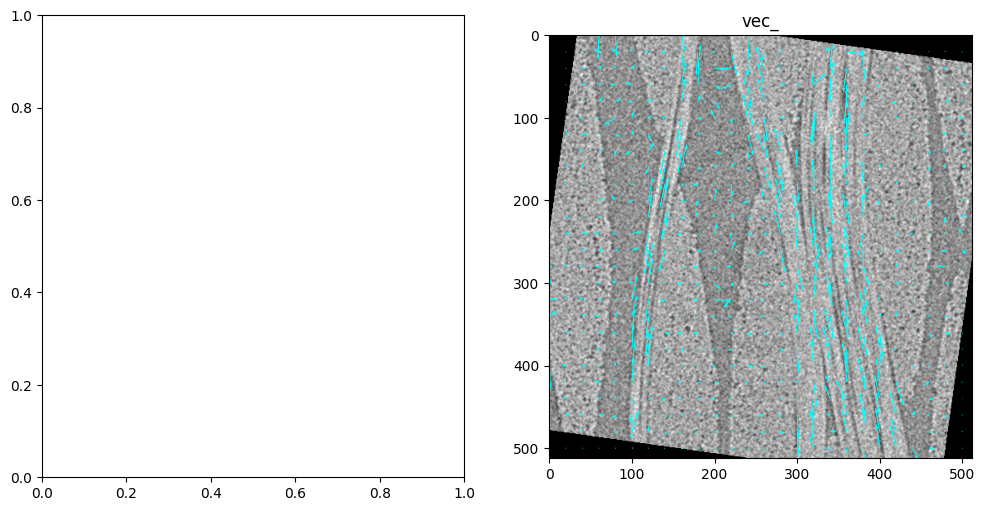

In [ ]:
slice_idx = 3

fig, axs = plt.subplots(1,2, figsize=(12,6))

# background
img = vol[slice_idx]

# vector components (choose in-plane components)
vy_ = vec_[1, slice_idx]
vx_ = vec_[0, slice_idx]

# subsample so arrows are readable
step = 20
Y, X = np.mgrid[0:img.shape[0]:step, 0:img.shape[1]:step]

axs[1].imshow(img, cmap="gray")
axs[1].quiver(
    X, Y,
    vx_[::step, ::step],
    vy_[::step, ::step],
    color="cyan",
    angles="xy",
    scale_units="xy",
    scale=None
)
axs[1].set_title("vec_")

plt.show()

In [ ]:
axes = ("x","z")

vec_aligned_ = align_direction(vec_.copy(), axes=axes)
# vec_aligned = align_direction(vec.copy(), axes=axes)

In [45]:
# cosine similarity on full 3D vectors
mean_cos, min_cos, max_ang = cosine_similarity(vec_aligned, vec_aligned_)
print("cos:", mean_cos, min_cos, max_ang)

# MSE/RMSE comparing the transformed vec__ to vec
mse = metric_mse(vec_aligned,vec_aligned_)
rmse = metric_rmse(vec_aligned,vec_aligned_)
print("mse/rmse:", mse, rmse)


cos: 0.9205673427796347 -0.9999794798485606 179.6329471050784
mse/rmse: 0.05295511447374503 0.23011978288218732


MSE  (slice 3): 2.845178e-02
RMSE (slice 3): 1.686765e-01
Cosine mean : 0.965754
Cosine min  : -1.000000
Max angle   : 180.000 deg


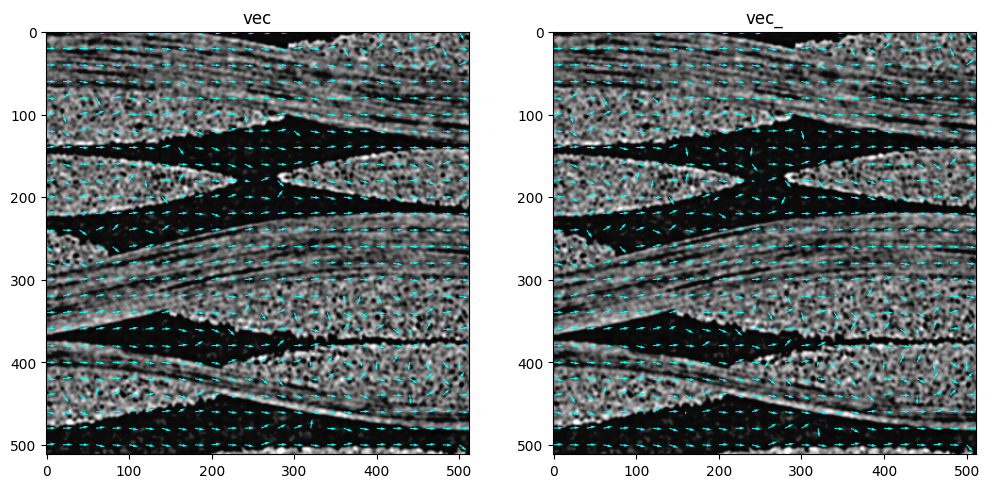

In [46]:
slice_idx = 3

fig, axs = plt.subplots(1,2, figsize=(12,6))

# background
img = vol[slice_idx]



# vector components (choose in-plane components)
vy = vec_aligned[1, slice_idx]   # Y component
vx = vec_aligned[0, slice_idx]   # X component

vy_ = vec_aligned_[1, slice_idx]
vx_ = vec_aligned_[0, slice_idx]


# -----------------------------------
# Build 2D vector fields for metrics
# -----------------------------------
vec_slice  = np.stack([vx,  vy],  axis=0)   # (2, H, W)
vec_slice_ = np.stack([vx_, vy_], axis=0)   # (2, H, W)

# -----------------------------------
# MSE / RMSE
# -----------------------------------
mse  = metric_mse(vec_slice, vec_slice_)
rmse = metric_rmse(vec_slice, vec_slice_)

print(f"MSE  (slice {slice_idx}): {mse:.6e}")
print(f"RMSE (slice {slice_idx}): {rmse:.6e}")

# -----------------------------------
# Cosine similarity (signed)
# -----------------------------------
mean_cos, min_cos, max_ang = cosine_similarity(
    vec_slice,
    vec_slice_,
    axis=0,                # vector components axis
    sign_invariant=False   # set True if eigenvector ambiguity
)

print(f"Cosine mean : {mean_cos:.6f}")
print(f"Cosine min  : {min_cos:.6f}")
print(f"Max angle   : {max_ang:.3f} deg")


# subsample so arrows are readable
step = 20
Y, X = np.mgrid[0:img.shape[0]:step, 0:img.shape[1]:step]

axs[0].imshow(img, cmap="gray")
axs[0].quiver(
    X, Y,
    vx[::step, ::step],
    vy[::step, ::step],
    color="cyan",
    angles="xy",
    scale_units="xy",
    scale=None
)
axs[0].set_title("vec")

axs[1].imshow(img, cmap="gray")
axs[1].quiver(
    X, Y,
    vx_[::step, ::step],
    vy_[::step, ::step],
    color="cyan",
    angles="xy",
    scale_units="xy",
    scale=None
)
axs[1].set_title("vec_")

plt.show()




In [47]:
def edge_aware_smooth_vec(v, iters=2, sigma_theta_deg=24.0, eps=1e-12):
    """
    Edge-aware smoothing for a line field (v ≡ -v). Preserves 90° jumps.
    v: (3,X,Y,Z)
    """
    v = v.copy()
    sigma_theta = np.deg2rad(sigma_theta_deg)

    def normed(x):
        n = np.linalg.norm(x, axis=0, keepdims=True)
        return x / (np.maximum(n, eps))

    v = normed(v)

    # 6-neighborhood shifts
    shifts = [(+1,0,0),(-1,0,0),(0,+1,0),(0,-1,0),(0,0,+1),(0,0,-1)]

    for _ in range(iters):
        acc = np.zeros_like(v)
        wsum = np.zeros(v.shape[1:], dtype=v.dtype)

        for dx,dy,dz in shifts:
            vn = np.roll(v, shift=(dx,dy,dz), axis=(1,2,3))

            # sign-invariant angle via abs(dot)
            c = np.abs(np.sum(v * vn, axis=0))
            c = np.clip(c, 0.0, 1.0)
            theta = np.arccos(c)

            w = np.exp(-(theta*theta) / (2*sigma_theta*sigma_theta)).astype(v.dtype)

            acc += vn * w[None, ...]
            wsum += w

        # include self weight
        acc += v
        wsum += 1.0

        v = acc / wsum[None, ...]
        v = normed(v)

    return v

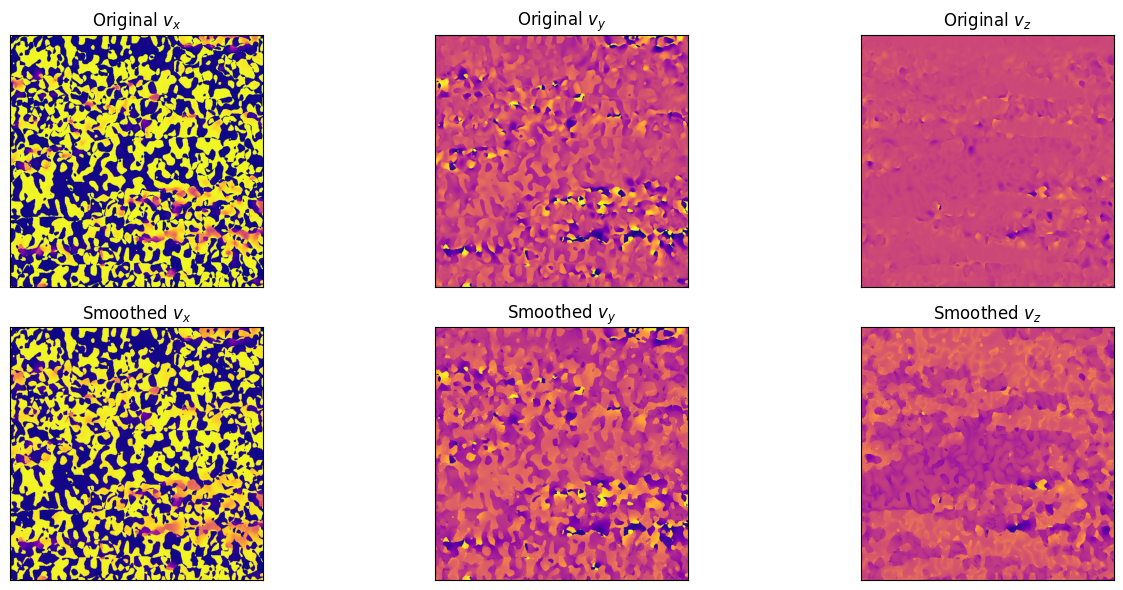

In [48]:
vec_smoothed = edge_aware_smooth_vec(vec,iters=100,sigma_theta_deg=10)

slice_idx = 0  # slice in X-direction

fig, axs = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True)

# ---------------------------
# Original vector components
# ---------------------------
axs[0,0].imshow(vec[0, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[0,0].set_title("Original $v_x$")

axs[0,1].imshow(vec[1, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[0,1].set_title("Original $v_y$")

axs[0,2].imshow(vec[2, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[0,2].set_title("Original $v_z$")

# ---------------------------
# Smoothed vector components
# ---------------------------
axs[1,0].imshow(vec_smoothed[0, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[1,0].set_title("Smoothed $v_x$")

axs[1,1].imshow(vec_smoothed[1, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[1,1].set_title("Smoothed $v_y$")

axs[1,2].imshow(vec_smoothed[2, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[1,2].set_title("Smoothed $v_z$")

# Cosmetic improvements
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [12]:
def debug_first_vectors(vec, vec__, n=20, y=0, z=0):
    print(f"Checking first {n} vectors at y={y}, z={z}\n")

    for x in range(min(n, vec.shape[1])):
        v  = vec[:, x, y, z]
        v_ = vec__[:, x, y, z]

        dot = np.dot(v, v_)
        norm_v  = np.linalg.norm(v)
        norm_v_ = np.linalg.norm(v_)

        cos = dot / (norm_v * norm_v_ + 1e-12)

        print(f"x = {x}")
        print(f"  vec   = {v[0]:.3f},{v[1]:.3f},{v[2]:.3f}")
        print(f"  vec__ = {v_[0]:.3f},{v_[1]:.3f},{v_[2]:.3f}")
        print(f"  dot   = {dot:.6f}")
        print(f"  cos   = {cos:.6f}")

        # check sign flip
        if np.allclose(v, -v_, atol=1e-6):
            print("  -> pure sign flip")

        # check component permutation
        for perm in [(0,1,2),(0,2,1),(1,0,2),(1,2,0),(2,0,1),(2,1,0)]:
            if np.allclose(v, v_[list(perm)], atol=1e-6):
                print(f"  -> component permutation {perm}")

        print("-" * 40)

In [13]:
debug_first_vectors(vec, vec__)

Checking first 20 vectors at y=0, z=0

x = 0
  vec   = 0.020,1.000,0.018
  vec__ = 0.007,-1.000,-0.013
  dot   = -0.999616
  cos   = -0.999616
----------------------------------------
x = 1
  vec   = 0.020,0.999,0.026
  vec__ = 0.000,-1.000,-0.015
  dot   = -0.999749
  cos   = -0.999749
----------------------------------------
x = 2
  vec   = 0.019,0.999,0.033
  vec__ = 0.008,1.000,0.016
  dot   = 0.999795
  cos   = 0.999795
----------------------------------------
x = 3
  vec   = 0.018,0.999,0.041
  vec__ = 0.015,1.000,0.015
  dot   = 0.999657
  cos   = 0.999657
----------------------------------------
x = 4
  vec   = 0.017,0.999,0.049
  vec__ = 0.022,1.000,0.009
  dot   = 0.999161
  cos   = 0.999161
----------------------------------------
x = 5
  vec   = 0.016,0.998,0.058
  vec__ = -0.027,-1.000,0.004
  dot   = -0.998008
  cos   = -0.998008
----------------------------------------
x = 6
  vec   = 0.015,0.998,0.066
  vec__ = -0.029,-0.999,0.024
  dot   = -0.995853
  cos   = -0.995853

In [40]:
def worst_voxels(vec, vec_, k=10, eps=1e-12):
    # normalize both
    a = vec / (np.linalg.norm(vec, axis=0, keepdims=True) + eps)
    b = vec_ / (np.linalg.norm(vec_, axis=0, keepdims=True) + eps)

    cos = np.sum(a*b, axis=0)  # (X,Y,Z)

    # flatten indices of smallest cos
    flat = np.argsort(cos.ravel())[:k]
    idx = np.array(np.unravel_index(flat, cos.shape)).T  # k x 3 -> (x,y,z)
    return cos, idx

cos, idx = worst_voxels(vec_ref, vec__, k=20)
print("Worst 10 cosine values:")
for (x,y,z) in idx:
    print((x,y,z), "cos =", float(cos[x,y,z]),
          "vec =", vec[:,x,y,z], "vec_ =", vec__[:,x,y,z])

Worst 10 cosine values:
(np.int64(0), np.int64(67), np.int64(54)) cos = 0.009346341513539191 vec = [0.00388383 0.9997358  0.02265489] vec_ = [2.31243103e-01 3.29073034e-04 9.72895945e-01]
(np.int64(2), np.int64(70), np.int64(54)) cos = 0.01258537866231638 vec = [0.00521741 0.99988174 0.01446583] vec_ = [0.33958852 0.00276594 0.94057003]
(np.int64(38), np.int64(107), np.int64(127)) cos = 0.015192796836754787 vec = [0.05728851 0.99835575 0.00194874] vec_ = [9.99912279e-01 1.32134794e-02 9.16035324e-04]
(np.int64(1), np.int64(66), np.int64(55)) cos = 0.016341356404058822 vec = [0.00864367 0.9999335  0.00763717] vec_ = [0.19048465 0.00640179 0.9816693 ]
(np.int64(0), np.int64(69), np.int64(54)) cos = 0.017793931739849327 vec = [0.0149334  0.99987996 0.0041362 ] vec_ = [0.23985718 0.00230469 0.97080545]
(np.int64(0), np.int64(66), np.int64(55)) cos = 0.019510555481859995 vec = [0.00954321 0.9998251  0.01608374] vec_ = [0.17679368 0.0072757  0.98422104]
(np.int64(1), np.int64(70), np.int64(5

In [ ]:
def align_to_other(v, v_ref, lib=np, inplace=False):
    """
    Flip v where dot(v, v_ref) < 0 so it matches v_ref's sign convention.
    v, v_ref: (..., 3) unit vectors
    """
    if not inplace:
        v = v.copy()
    dot = (v * v_ref).sum(axis=-1)
    flip = dot < 0
    v[flip] *= -1
    return v

In [ ]:
out_path = file_path.with_name(
    file_path.name.replace("..vol.vec.gzip.test.h5", ".vol.vec.gzip.test.results.h5")
)

print(out_path)